# Synthetic-ensemble figures (CSV-driven)

Reproduces the three synthetic-ensemble figures from the **saved** results at the locked joint
optimum — no model re-run, reads CSVs only. Mirrors `scripts/synth_figures_from_csv.py`.

| figure | source | shows |
|---|---|---|
| `synth_paths`   | `output/overnight_joint/paths/fv_joint_s*.csv` | the synthetic stress-path ensemble $V_t$ |
| `synth_facts`   | `output/synth_results/mids_noclr/ret_s*.csv` | tails (CCDF) + clustering (\|r\|-ACF), **bare-market** returns (the calibration target) |
| `synth_clearing`| `output/synth_results/{summary,im_path}.csv`  | client defaults vs path vol; posted-IM band |

Note: the facts use **no-clearing** returns (`mids_noclr/`, from `scripts/gen_noclr.py`) because the
calibration/validation is on the bare market; the with-clearing returns (`mids/`) damp the clustering.

In [1]:
import matplotlib.figure as _mfig, matplotlib.axes as _maxes
_mfig.Figure.suptitle = lambda *a, **k: None
%matplotlib inline
import os, glob, re
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scripts.calibrate import _empirical_returns, _acf

SR, PATHS, OUT, MAXLAG = 'output/synth_results', 'output/overnight_joint/paths', 'output/results', 30
os.makedirs(OUT, exist_ok=True)
STEEL, NAVY, BLACK, GREY = '#7FB3D5', '#1A5276', '#1A5276', '#9aa5b1'
plt.rcParams.update({'axes.grid': True, 'grid.alpha': 0.25, 'axes.axisbelow': True, 'font.size': 11})
_num = lambda f: int(re.search(r'_s(\d+)\.csv$', f).group(1))
_ccdf = lambda x: (np.sort(np.abs(x)/np.std(x))[::-1], np.arange(1, len(x)+1)/len(x))

emp = _empirical_returns('stressed'); emp = emp[np.isfinite(emp)]
rets = [pd.read_csv(f)['ret'].to_numpy() for f in sorted(glob.glob(f'{SR}/mids_noclr/ret_s*.csv'), key=_num)]
rets = [r[np.isfinite(r)] for r in rets if len(r) > 100]
print(len(rets), 'no-clearing return paths loaded')

30 no-clearing return paths loaded


## 1. Price-path ensemble — `synth_paths.png`

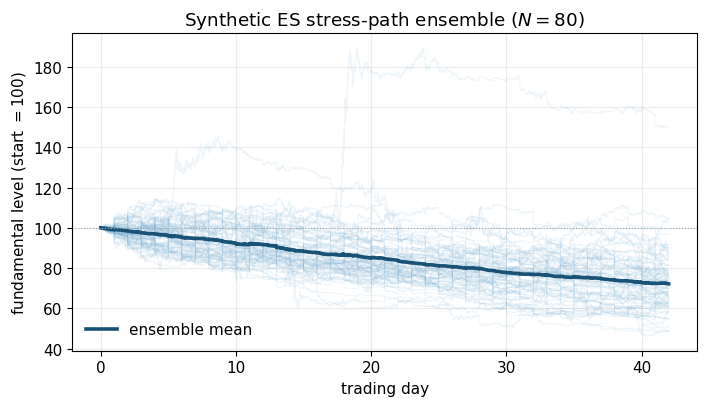

In [2]:
Vs = [pd.read_csv(f)['V_smooth'].to_numpy() for f in sorted(glob.glob(f'{PATHS}/fv_joint_s*.csv'), key=_num)]
L = min(map(len, Vs)); Vs = np.array([v[:L] for v in Vs]); norm = 100*Vs/Vs[:, [0]]; idx = np.arange(L)/390
fig, ax = plt.subplots(figsize=(7.2, 4.2))
for r in norm: ax.plot(idx, r, color=STEEL, alpha=0.12, lw=0.7)
ax.plot(idx, norm.mean(0), color=NAVY, lw=2.6, label='ensemble mean'); ax.axhline(100, color=GREY, ls=':', lw=0.8)
ax.set_xlabel('trading day'); ax.set_ylabel('fundamental level (start $=100$)')
ax.set_title(f'Synthetic ES stress-path ensemble ($N={len(Vs)}$)'); ax.legend(frameon=False, loc='lower left')
fig.tight_layout(); fig.savefig(f'{OUT}/synth_paths.png', dpi=160, bbox_inches='tight'); plt.show()

## 2. Stylised facts — `synth_facts.png` (tails + clustering, bare market)

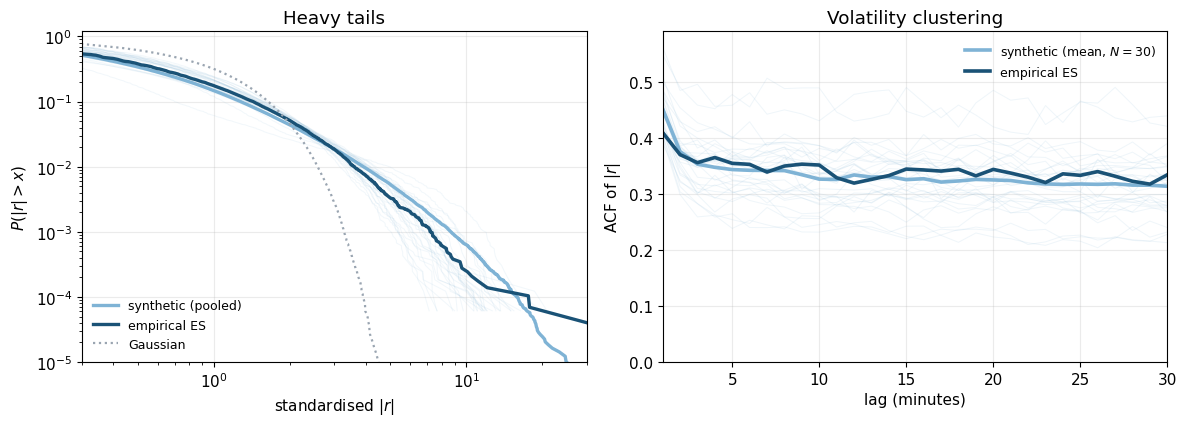

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
for r in rets:
    zx, zy = _ccdf(r); ax[0].loglog(zx, zy, color=STEEL, alpha=0.10, lw=0.7)
zx, zy = _ccdf(np.concatenate(rets)); ax[0].loglog(zx, zy, color=STEEL, lw=2.4, label='synthetic (pooled)')
ex, ey = _ccdf(emp); ax[0].loglog(ex, ey, color=BLACK, lw=2.4, label='empirical ES')
gx, gy = _ccdf(np.random.default_rng(0).normal(size=300000)); ax[0].loglog(gx, gy, color=GREY, ls=':', lw=1.6, label='Gaussian')
ax[0].set_xlim(0.3, 30); ax[0].set_ylim(1e-5, 1.2); ax[0].set_xlabel('standardised $|r|$'); ax[0].set_ylabel(r'$P(|r|>x)$')
ax[0].set_title('Heavy tails'); ax[0].legend(frameon=False, fontsize=9, loc='lower left')
lags = np.arange(1, MAXLAG+1); acfs = np.array([[_acf(np.abs(r), k) for k in lags] for r in rets])
for row in acfs: ax[1].plot(lags, row, color=STEEL, alpha=0.12, lw=0.7)
ax[1].plot(lags, acfs.mean(0), color=STEEL, lw=2.6, label=f'synthetic (mean, $N={len(rets)}$)')
ax[1].plot(lags, [_acf(np.abs(emp), k) for k in lags], color=BLACK, lw=2.6, label='empirical ES')
ax[1].axhline(0, color=GREY, lw=0.6); ax[1].set_xlim(1, MAXLAG); ax[1].set_ylim(bottom=0)
ax[1].set_xlabel('lag (minutes)'); ax[1].set_ylabel(r'ACF of $|r|$'); ax[1].set_title('Volatility clustering')
ax[1].legend(frameon=False, fontsize=9)
fig.suptitle('Synthetic two-factor log-volatility ensemble reproduces the ES stylised facts', fontweight='bold', y=1.01)
fig.tight_layout(); fig.savefig(f'{OUT}/synth_facts.png', dpi=160, bbox_inches='tight'); plt.show()

## 3. Clearing outcomes — `synth_clearing.png`

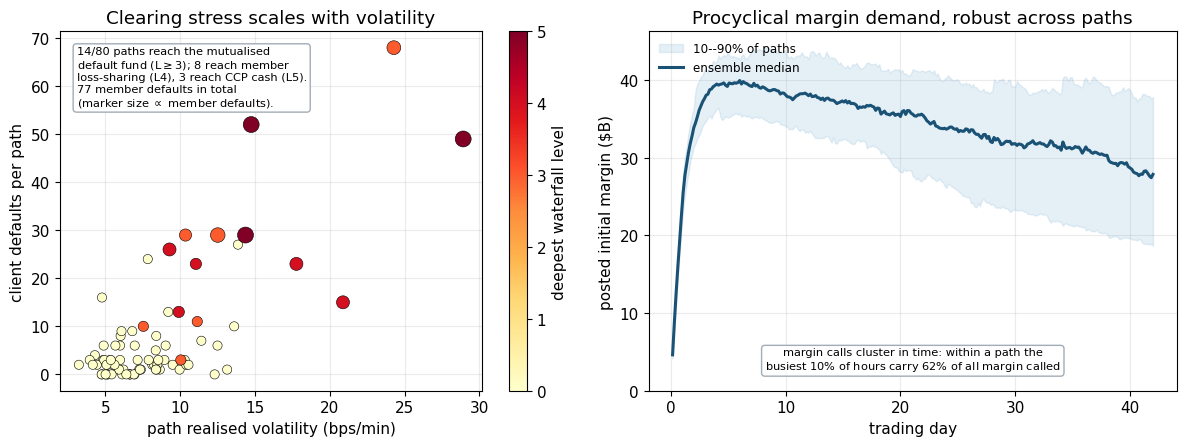

client_def median 3 mean 7.8 max 68 | member def 77 on 14 paths | L>=3 14/80 (L4 8, L5 3) | within-path busiest-10% carry 62% of calls


In [4]:
summ = pd.read_csv(f'{SR}/summary.csv')
clr_files = sorted(glob.glob(f'{SR}/mids/ret_s*.csv'), key=_num)
summ['vol_bps'] = summ['path'].map({_num(f): np.std(pd.read_csv(f)['ret'])*1e4 for f in clr_files})
nmut = int((summ['deepest_wf']>=3).sum()); n4 = int((summ['deepest_wf']>=4).sum()); n5 = int((summ['deepest_wf']>=5).sum())

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
# (a) clearing severity vs path volatility, coloured by deepest waterfall level (benign first, tail on top)
o = summ.sort_values('deepest_wf').index
sc = ax[0].scatter(summ.loc[o,'vol_bps'], summ.loc[o,'client_def'], c=summ.loc[o,'deepest_wf'],
                   cmap='YlOrRd', vmin=0, vmax=5, s=44+11*summ.loc[o,'cm_def'].clip(0,8),
                   edgecolor='k', lw=0.4, zorder=3)
fig.colorbar(sc, ax=ax[0], ticks=range(6)).set_label('deepest waterfall level')
ax[0].set_xlabel('path realised volatility (bps/min)'); ax[0].set_ylabel('client defaults per path')
ax[0].set_title('Clearing stress scales with volatility')
ax[0].text(0.04, 0.96, f"{nmut}/{len(summ)} paths reach the mutualised\ndefault fund (L$\\geq$3); {n4} reach member\nloss-sharing (L4), {n5} reach CCP cash (L5).\n{int(summ['cm_def'].sum())} member defaults in total\n(marker size $\\propto$ member defaults).",
           transform=ax[0].transAxes, ha='left', va='top', fontsize=8.2,
           bbox=dict(boxstyle='round', fc='white', ec=GREY, alpha=0.92))

# (b) posted IM level, ensemble median + 10-90% band. Margin-call CLUSTERING is WITHIN-path
#     (each path's vol clusters at different times -> a cross-path average washes it out), so it is
#     reported as a within-path statistic rather than an (misleading) ensemble-mean time series.
im = pd.read_csv(f'{SR}/im_path.csv'); g = im.groupby('t')['im_total']
med, lo, hi = g.median()/1e9, g.quantile(0.10)/1e9, g.quantile(0.90)/1e9; d = med.index.to_numpy()/390
shares = []
for p, grp in im.groupby('path'):
    s = grp.sort_values('t'); dd = np.clip(np.diff(s['im_total'].to_numpy()), 0, None)
    dd = dd[s['t'].to_numpy()[1:] >= 390]
    if dd.sum() > 0: shares.append(np.sort(dd)[::-1][:max(1, len(dd)//10)].sum()/dd.sum())
clust = 100*np.mean(shares)
ax[1].fill_between(d, lo, hi, color=STEEL, alpha=0.20, label='10--90% of paths')
ax[1].plot(d, med, color=NAVY, lw=2.2, label='ensemble median')
ax[1].set_xlabel('trading day'); ax[1].set_ylabel('posted initial margin (\\$B)'); ax[1].set_ylim(bottom=0)
ax[1].set_title('Procyclical margin demand, robust across paths')
ax[1].text(0.5, 0.05, f'margin calls cluster in time: within a path the\nbusiest $10\\%$ of hours carry ${clust:.0f}\\%$ of all margin called',
           transform=ax[1].transAxes, ha='center', va='bottom', fontsize=8.2,
           bbox=dict(boxstyle='round', fc='white', ec=GREY, alpha=0.92))
ax[1].legend(frameon=False, fontsize=8.6, loc='upper left')
fig.suptitle('Clearing on the synthetic stressed ensemble: robust on the median path, with a volatility-driven tail',
             fontweight='bold', y=1.02)
fig.tight_layout(); fig.savefig(f'{OUT}/synth_clearing.png', dpi=160, bbox_inches='tight'); plt.show()
print(f"client_def median {summ['client_def'].median():.0f} mean {summ['client_def'].mean():.1f} max {summ['client_def'].max()} | "
      f"member def {int(summ['cm_def'].sum())} on {int((summ['cm_def']>0).sum())} paths | "
      f"L>=3 {nmut}/{len(summ)} (L4 {n4}, L5 {n5}) | within-path busiest-10% carry {clust:.0f}% of calls")

## 4. Takeaway
On unseen calibrated stress paths the two-factor log-volatility ensemble keeps the ES heavy tails and
volatility clustering (bare market), and the cleared market is **robust on the median path** — 3 client
defaults, no member default, no mutualisation, matching the single COVID replay. The ensemble's value is the
**tail it reveals**: 14/80 paths draw the mutualised default fund (L≥3), 8 reach surviving-member
loss-sharing (L4), 3 reach CCP cash (L5), with 77 member defaults concentrated there. What drives the tail is
**realised volatility, not the drawdown** (r≈0.7–0.9 vs ≈0), and the margin calls cluster in time (within a
path the busiest 10% of hours carry 62% of all margin called) — the procyclical, clustered collateral demand
that is the emergent counterpart of the fundamental's volatility clustering.